### Stochastic interpolant with **equivariant OT**: semiflexible chain → tangentially active polymer

A tangentially active polymer (TAP) is a bead-spring chain driven by a force along its own
local backbone tangent. Two features set it apart from the LJ13 cluster, and both are visible
in the code below:

* **It is a directed object.** The active force follows the chain from tail to head, so
  relabelling monomers is *not* a symmetry. The OT coupling therefore optimizes over **O(3)
  alone** — no permutation layer — and the velocity field is handed the chain explicitly, as
  a positional embedding of each monomer's place along the backbone and a bonded/non-bonded
  flag on every edge, so that it can tell monomer 1 from monomer 7 at all.
* **It is out of equilibrium.** The drive is non-conservative: there is no potential $U(x)$,
  no Boltzmann target, and no free energy to reweight toward. Nothing in this notebook
  computes $\Delta F$, because no importance-sampling estimator exists to compute it with.
  The interpolant entropy is the point — it is reachable precisely where reweighting is not.

Translations are gauge-fixed by pinning the **tail** (particle 0) at the origin, so
configurations live on a $3(N-1)$-dimensional subspace and rotations act about that pinned
point rather than about the centroid.

The base distribution is the same polymer with the **activity and the excluded volume
switched off**: harmonic bonds of stiffness $k$ about a finite equilibrium length $b$, plus a
harmonic bending potential $\gamma(\cos\theta - \cos\theta_0)^2$ between successive bonds.
Its four parameters are calibrated from the reference data in §1, so the flow starts from
something already the right size and stiffness and only has to supply what activity does on
top of that.

### 0. Imports & environment

In [1]:
# --- imports & environment ---
import sys
import pathlib
import time

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

# Make the `eesi` package importable whether the notebook is launched from the
# repo root or from this experiments/ folder (no install required).
_cwd = pathlib.Path.cwd()
for _root in (_cwd, _cwd.parent, _cwd.parent.parent):
    if (_root / "eesi" / "__init__.py").exists():
        sys.path.insert(0, str(_root))
        break

from eesi.systems.tap.data import (
    REF_DATA_PATH, load_ref_data, sample_prior, log_prior, prior_entropy,
    prior_energy, prior_free_energy, bending_deltas,
    bond_vectors, bond_cosines, bond_moments, angle_moments,
    end_to_end_sq, end_to_end_mean_sq, gyration_sq, solve_cos_theta_0, dof,
    rouse_modes, rouse_mode_moments,
)
from eesi.systems.tap.dynamics import TAPDynamics, rk4_sample, integrate_with_logdet
from eesi.systems.tap.ot import tap_ot_couple, tap_cost_matrix
from eesi.systems.tap.train import make_si_model, train_si, tap_step
from eesi.ot import transport_cost

%matplotlib inline
torch.set_default_dtype(torch.float64)   # the train hooks default to float64
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


#### 0.1. Some useful functions

In [2]:
N       = 20        # monomers
DOF     = dof(N)    # 3 (N-1) = 57

# The prior's four parameters are calibrated from the reference data in section 1,
# not set by hand -- see the cell after the dataset loads.

def bond_lengths(x):                     # (B,N,3) -> (B*(N-1),)
    return bond_vectors(x).norm(dim=-1).reshape(-1).cpu().numpy()

# <u_i . u_{i+k}> for unit bond tangents: the shape signature of an active chain.
# A freely-jointed chain decorrelates immediately (delta_{k0}); bending rigidity and
# activity both stiffen the backbone and make this decay slowly, so it is the cleanest
# single curve for telling prior and target apart -- and now for checking how much of
# the target's stiffness the prior already reproduces.
def tangent_correlation(x):
    u = bond_vectors(x)
    u = u / u.norm(dim=-1, keepdim=True)
    nb = u.shape[1]
    return np.array([(u[:, :nb-k] * u[:, k:]).sum(-1).mean().item() for k in range(nb)])

def smooth(v, k=10):
    v = np.asarray(v)
    return np.convolve(v, np.ones(k) / k, mode="valid") if len(v) >= k else v

# Apply a sampler to x0 in chunks: the ODE/SDE have no batch coupling, so this is
# exactly equivalent to one big call and only caps peak GPU memory.
@torch.no_grad()
def chunked(fn, x0, size=500):
    return torch.cat([fn(c) for c in x0.split(size)])

### 1. Datasets & samplers

The base distribution is a **semiflexible chain**: $N-1$ bonds whose magnitudes follow a
harmonic spring of stiffness $k$ about a finite equilibrium length $b$, with successive bonds
coupled by a bending potential $\gamma(\cos\theta - \cos\theta_0)^2$. Writing
$u = \cos\theta = \hat u_j\cdot\hat u_{j-1}$, the solid-angle element
$\sin\theta\,d\theta\,d\phi = du\,d\phi$ leaves the azimuth uniform and $u$ a Gaussian
**truncated to $[-1,1]$**:

$$p(Q) \propto Q^2 e^{-\frac{k}{2}(Q-b)^2},\qquad
  p(u) \propto e^{-\gamma(u-u_0)^2},\quad u\in[-1,1].$$

The log-density is exact — the bond-to-position map is unit lower triangular and each bond's
change to its predecessor's frame is a rotation, so no Jacobian correction appears:

$$\log p_0(x) = -\sum_j \tfrac{k}{2}(Q_j-b)^2 - \gamma\sum_{j\ge2}(u_j-u_0)^2
  - \log(4\pi Z_1) - (N-2)\log(2\pi Z_1 Z_{\rm ang}).$$

Note the $4\pi$ / $2\pi$ asymmetry: only the first bond is isotropic and normalizes over the
full sphere, so there are $N-1$ radial factors but only $N-2$ angular ones.

**Calibration.** Three of the four parameters are *measured* from the reference data
($k = 1/\mathrm{var}(Q)$, $b = \mathbb{E}[Q]$, $\gamma = 1/(2\,\mathrm{var}(\cos\theta))$) and
the fourth, $\cos\theta_0$, is *fitted* so the prior's $\mathbb{E}[R_e^2]$ matches the data's.
That last one is deliberate: the real chain's angular correlations decay slower than the
geometric law any nearest-neighbour bending potential can produce, so matching the observed
$\langle\cos\theta\rangle$ would leave the chain too small. $\cos\theta_0$ buys the correct
global size instead, and the gap between the two is printed below so it stays visible.

In [12]:
# --- target: the reference TAP configurations ---
#
# Generated externally (Brownian dynamics of the active chain) and written as a .npy of
# shape (M, N, 3) or (M, N*3), tail already at the origin. Point `DATA` wherever yours is.
#
# This cell comes FIRST because the prior is calibrated from it: the four parameters
# below are measured off these configurations, not chosen by hand.
DATA = REF_DATA_PATH
print(DATA)
n_data = 1_000_000
x1 = load_ref_data(DATA, n=n_data, n_particles=N).to(device)

print("target dataset:", tuple(x1.shape))
print(f"E[Re^2] = {end_to_end_sq(x1).mean():.4f}   E[Rg^2] = {gyration_sq(x1).mean():.4f}"
      f"   Re^2/Rg^2 = {(end_to_end_sq(x1).mean()/gyration_sq(x1).mean()):.4f}")

/home/pmr8460/Projects/eesi/data/tap_N20_Pe0.npy
target dataset: (1000000, 20, 3)
E[Re^2] = 44.3005   E[Rg^2] = 6.8505   Re^2/Rg^2 = 6.4667


In [13]:
# --- calibrate the prior from the data, then check it ---
#
# Three parameters are MEASURED off the reference configurations; the fourth is FITTED.
# Nothing here is hand-tuned, so re-running against a different dataset re-derives them.
_q   = bond_vectors(x1).norm(dim=-1)
_cos = bond_cosines(x1)

#K_BOND   = 1.0 / _q.var().item()              # harmonic bond stiffness
K_BOND   = 100.0              # harmonic bond stiffness
#B_BOND   = _q.mean().item()                   # equilibrium bond length
B_BOND   = 1.0                   # equilibrium bond length
GAMMA_BEND = 0.0
COS_THETA_0 = 0.0
#GAMMA_BEND = 1.0 / (2.0 * _cos.var().item())  # bending constant
#COS_THETA_0 = solve_cos_theta_0(              # fitted so E[Re^2] matches the data
#    K_BOND, B_BOND, GAMMA_BEND, end_to_end_sq(x1).mean().item(), N)

print(f"k = {K_BOND:.4f}   b = {B_BOND:.4f}   gamma = {GAMMA_BEND:.4f}   "
      f"cos_theta_0 = {COS_THETA_0:.4f}")

# The one number that is fitted rather than measured, and by how much it differs from
# what the data actually shows. The gap is expected: a nearest-neighbour bending
# potential gives geometrically decaying correlations, <u_i.u_j> = <u>^|i-j|, while the
# real chain's decay is slower (excluded volume). Matching <cos theta> would leave the
# prior too small, so cos_theta_0 over-stiffens deliberately to buy the right size.
print(f"\nprior <cos theta> = {angle_moments(GAMMA_BEND, COS_THETA_0)[1]:+.4f}   "
      f"(data {_cos.mean():+.4f})   <- deliberately over-stiffened")

x0_check = sample_prior(1_000_000, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, n_particles=N)
print(f"\n{'':<12}{'E[Re^2]':>10}{'E[Rg^2]':>10}{'E[|b|^2]':>10}")
print(f"{'prior':<12}{end_to_end_sq(x0_check).mean():10.4f}{gyration_sq(x0_check).mean():10.4f}"
      f"{(bond_vectors(x0_check)**2).sum(-1).mean():10.4f}")
print(f"{'data':<12}{end_to_end_sq(x1).mean():10.4f}{gyration_sq(x1).mean():10.4f}"
      f"{(bond_vectors(x1)**2).sum(-1).mean():10.4f}")
print(f"{'analytic':<12}{end_to_end_mean_sq(K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, N):10.4f}"
      f"{'':>10}{bond_moments(K_BOND, B_BOND)[2]:10.4f}")

# The analytic entropy of the prior, the reference point that turns the estimated dS of
# section 5 into an absolute S[p1]. The MC value beside it is the check that the
# normalizer -- the 4 pi / 2 pi split above -- is right.
S_prior = prior_entropy(K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, N)
_mc = -log_prior(x0_check, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0).mean()
print(f"\nS[p0] (analytic) = {S_prior:+.4f} nats     -E[log p0] = {_mc:+.4f}")
del x0_check

k = 100.0000   b = 1.0000   gamma = 0.0000   cos_theta_0 = 0.0000

prior <cos theta> = +0.0000   (data +0.2530)   <- deliberately over-stiffened

               E[Re^2]   E[Rg^2]  E[|b|^2]
prior          19.9763    3.4935    1.0497
data           44.3005    6.8505    1.0598
analytic       19.9462              1.0498

S[p0] (analytic) = +31.6774 nats     -E[log p0] = +31.6742


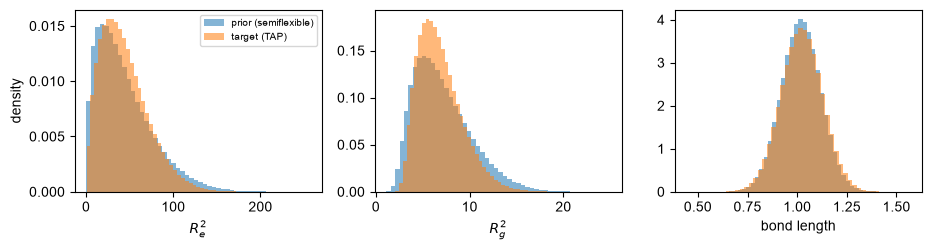

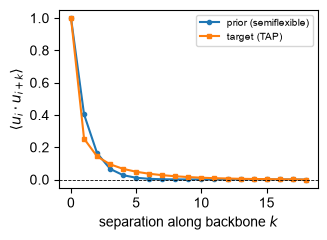

In [12]:
# --- prior vs target: where the flow has to do work ---
x0_ref = sample_prior(1_000_000, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                      n_particles=N, device=device)

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.6))
for a, (v0, v1, lab) in zip(ax, [
    (end_to_end_sq(x0_ref).cpu(), end_to_end_sq(x1).cpu(), r"$R_e^2$"),
    (gyration_sq(x0_ref).cpu(),   gyration_sq(x1).cpu(),   r"$R_g^2$"),
    (bond_lengths(x0_ref),        bond_lengths(x1),        "bond length"),
]):
    a.hist(np.asarray(v0), bins=50, density=True, alpha=0.55, label="prior (semiflexible)")
    a.hist(np.asarray(v1), bins=50, density=True, alpha=0.55, label="target (TAP)")
    a.set_xlabel(lab)
ax[0].set_ylabel("density"); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

# The tangent correlation is where the calibration's one compromise is visible. The
# prior matches at k=0 and k=1 by construction and then decays geometrically, while the
# data's decay is slower; the prior's lag-1 value sits ABOVE the data's, which is the
# over-stiffening that buys the correct E[Re^2].
fig, a = plt.subplots(figsize=(3.375, 2.5))
a.plot(tangent_correlation(x0_ref), 'o-', ms=3, label="prior (semiflexible)")
a.plot(tangent_correlation(x1), 's-', ms=3, label="target (TAP)")
a.axhline(0, c="k", lw=0.6, ls="--")
a.set_xlabel("separation along backbone $k$"); a.set_ylabel(r"$\langle u_i \cdot u_{i+k}\rangle$")
a.legend(fontsize=7); plt.tight_layout(); plt.show()

### 2. The coupling

`tap_ot_couple` optimizes over **O(3)** and the batch assignment. Two things it deliberately
does *not* do, both checked in `tests/tap/test_tap_ot.py`:

* it never **centers** — rotations act about the pinned tail, and centering would push the
  chain off the subspace the prior and the divergence basis are defined on;
* it never **permutes** monomers — that would identify configurations the active dynamics
  distinguishes.

Because the permutation stage is gone, orthogonal Procrustes solves the whole group exactly,
so unlike LJ13 the alignment here is *exactly* equivariant.

In [7]:
batch_size = 256
torch.manual_seed(9448)

idx = torch.randint(0, x1.shape[0], (batch_size,), device=device)
xb  = x1[idx]
xa  = sample_prior(batch_size, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                   n_particles=N, device=device)

cells_2x2 = {}
for align in (True, False):
    for batch in (True, False):
        a, b = tap_ot_couple(xa, xb, align=align, batch=batch)
        cells_2x2[(align, batch)] = transport_cost(a, b).item()

base = cells_2x2[(False, False)]
print(f"{'align':>6} {'batch':>6} {'transport':>11} {'vs random':>10}")
for (al, ba), c in cells_2x2.items():
    print(f"{str(al):>6} {str(ba):>6} {c:11.4f} {100*(c/base-1):9.1f}%")

a, b = tap_ot_couple(xa, xb)
print(f"\ntail row after coupling: |x0[:,0]| = {a[:,0].abs().max():.2e}, "
      f"|x1[:,0]| = {b[:,0].abs().max():.2e}   (must be 0: the gauge is pinned)")

 align  batch   transport  vs random
  True   True     32.7143     -96.2%
  True  False    145.7427     -83.0%
 False   True    121.1051     -85.9%
 False  False    859.4164       0.0%

tail row after coupling: |x0[:,0]| = 0.00e+00, |x1[:,0]| = 0.00e+00   (must be 0: the gauge is pinned)


### 3. Training with equivariant OT

Two `TAPDynamics` fields (drift and score) share the LJ13 E(n)-GNN backbone from `eesi.egnn`.
The wrapper differs in three ways.

**The projection.** The output velocity is projected onto $\{v : v_0 = 0\}$ rather than onto
the COM-free subspace.

**The node features.** Each node carries the interpolant time $t$ *and* its normalized chain
position $s = i/(N-1)$, and both are expanded into **half-period Fourier features**,
$[\cos(\pi k s), \sin(\pi k s)]$ for $k = 1\ldots K$, before the single `Linear` embedding.
A raw scalar gives that layer almost nothing to condition on — every downstream MLP would
have to build its own nonlinear basis out of a one-dimensional ramp before it could resolve
monomer 7 from monomer 8. Half-period, not full: $\cos(2\pi k s)$ has period exactly 1 and
so maps $s=0$ and $s=1$ to the *same* vector, collapsing the tail with the head and $t=0$
with $t=1$. Setting `time_order=index_order=0` feeds the raw scalars alone.

**The edge attributes.** Each edge carries a **bonded/non-bonded flag**, $1$ if $|i-j|=1$ and
$0$ otherwise. This replaces a channel that was dead weight: the wrapper used to pass
$\|x_i - x_j\|^2$, which is bit-identical to the `radial` term `E_GCL` already computes for
itself. Handing over the topology instead costs nothing and removes an inference the net was
previously forced to make from geometry — an unreliable one here, since neither the prior nor
the target has excluded volume, so a non-bonded pair can sit closer than a bond length.

Either chain feature alone breaks $S(N)$-equivariance, and without both the network literally
cannot represent a directed chain's velocity field — set `index_feature=False,
bond_feature=False` to recover the bare LJ13 net and watch it fail.

In [7]:
torch.manual_seed(20)
batch_size = 256
model = make_si_model(n_particles=N, n_dims=3, hidden_nf=32, n_layers=3,
                      index_feature=True, bond_feature=True,
                      time_order=4, index_order=4,
                      path="linear", gamma="sqrt",
                      gamma_scale=0.2, learn_score=False)
model = model.to(device)
# Loss history, accumulated across repeated runs of the next cell. Its column count
# is set by that cell's `entropy=` argument (2 without it, 4 with "both"), so
# re-run this cell to clear `htot` before changing the flag -- the unpack there
# needs every row the same width.
htot = []
print(f"parameters: {sum(p.numel() for p in model.parameters()):,}   "
      f"in_node_nf = {model.net_b.egnn.embedding.in_features}")

parameters: 47,146   in_node_nf = 18


In [8]:
model.net_b.load_state_dict(torch.load(f"tap_b_si_N{N}_B{batch_size}.pth"))
model.net_s.load_state_dict(torch.load(f"tap_s_si_N{N}_B{batch_size}.pth"))


<All keys matched successfully>

In [ ]:
torch.manual_seed(9340)
t_start = time.perf_counter()

# entropy="both" logs the two interpolant estimators per batch alongside the losses:
# S_dot = -<b.s> with the learned score, S_zdot = -<b.z/gamma> with the exact
# conditional score the draw already carries. Both come out of the draw `model.loss`
# has already made, so they cost no extra network evaluation. Watch them converge
# DURING the run; the arbiter for the model stays the generated-sample statistics
# below, and the batch estimates in section 5 are what these should settle toward.
model, hist = train_si(x1, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                       model=model, steps=20_000, batch_ot=True, batch=batch_size,
                       lr=1e-4, device=str(device), log_every=10, entropy="both")
htot += hist

hist_b, hist_s, ent_dot, ent_zdot = map(np.asarray, zip(*htot))
print(f"total {time.perf_counter()-t_start:.0f}s")

np.save("tap_train_hist.npy",np.array(htot))

torch.save(model.net_b.state_dict(), f"tap_b_si_N{N}_B{batch_size}.pth")
torch.save(model.net_s.state_dict(), f"tap_s_si_N{N}_B{batch_size}.pth")
print(f"saved tap_{{b,s}}_si_N{N}_B{batch_size}.pth")

  step     0  loss_b   -1.7219  loss_s -788.6207  S_dot    0.6168  S_zdot    2.4240  transport  30.055  (  0.4s)
  step    10  loss_b   -3.2939  loss_s -392.7696  S_dot   -9.8440  S_zdot   -0.4688  transport  32.750  (  3.0s)
  step    20  loss_b   -3.0172  loss_s -600.0389  S_dot   -5.3162  S_zdot   -2.0309  transport  32.725  (  5.6s)
  step    30  loss_b   -3.3203  loss_s -695.3080  S_dot    1.1605  S_zdot    0.1980  transport  32.482  (  8.2s)
  step    40  loss_b   -3.1887  loss_s -753.6927  S_dot   -4.5570  S_zdot   -1.0851  transport  33.997  ( 10.9s)
  step    50  loss_b   -3.1799  loss_s -784.4191  S_dot   -1.5421  S_zdot    0.3826  transport  31.037  ( 13.5s)
  step    60  loss_b   -3.3234  loss_s -792.5861  S_dot   -3.0459  S_zdot   -2.2209  transport  32.758  ( 16.2s)
  step    70  loss_b   -3.0419  loss_s -780.3153  S_dot    0.2564  S_zdot    1.6224  transport  31.355  ( 18.8s)
  step    80  loss_b   -3.0854  loss_s -797.0883  S_dot   -2.7150  S_zdot   -1.7569  transport  

In [9]:
htot = np.load("tap_train_hist.npy")
hist_b, hist_s, ent_dot, ent_zdot = map(np.asarray, zip(*htot))

In [3]:
df = pd.read_csv("../../runs/tap_Pe0p1/history.csv")
df.columns

Index(['global_step', 'stage', 'stage_step', 'loss_b', 'loss_s', 'S_dot',
       'S_zdot', 'transport', 'elapsed_s'],
      dtype='str')

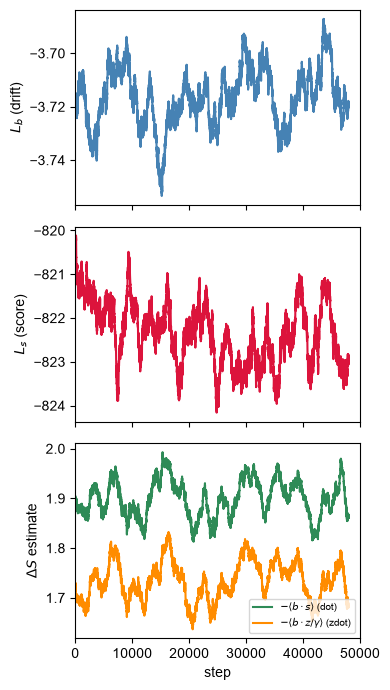

In [4]:
hist_b = df.loss_b
hist_s = df.loss_s
ent_dot = df.S_dot
ent_zdot = df.S_zdot

fig, ax = plt.subplots(3, 1, sharex=True, figsize=(4, 7))
ax[0].plot(smooth(hist_b,2000), c="steelblue"); ax[0].set_ylabel(r"$L_b$ (drift)")
ax[1].plot(smooth(hist_s,2000), c="crimson");   ax[1].set_ylabel(r"$L_s$ (score)")
# The two entropy channels differ only in which score enters -b.s: the learned net_s
# ("dot") or the exact conditional score -z/gamma ("zdot"). "zdot" is unbiased for the
# TRUE score whatever net_s has learned, so a persistent gap between the traces is a
# statement about net_s, not about the estimator. There is no dF reference line here --
# an active polymer has no target potential to reweight against.
ax[2].plot(smooth(ent_dot,2000),  c="seagreen", label=r"$-\langle b\cdot s\rangle$ (dot)")
ax[2].plot(smooth(ent_zdot,2000), c="darkorange", label=r"$-\langle b\cdot z/\gamma\rangle$ (zdot)")
ax[2].set_ylabel(r"$\Delta S$ estimate"); ax[2].legend(fontsize=7)
ax[2].set_xlabel("step")
#for a in ax: a.set_yscale("symlog")
#ax[0].set_ylim(-4,-3)
#ax[1].set_ylim(-850,-750)
#ax[2].set_ylim(0,2.25)
ax[2].set_xlim(0,50000)
plt.tight_layout(); plt.show()

In [5]:
bootstrap = lambda data: np.mean(np.random.choice(data,len(data),replace=True))
straps = np.array([bootstrap(ent_zdot[-1000:]) for _ in range(10000)])
print(np.mean(straps))
print(1.96*np.std(straps))



1.6525481950483096
0.07418205796857431


### 4. Sampling

In [13]:
torch.manual_seed(4)

x0 = sample_prior(100_000, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                  n_particles=N, device=device)
x_gen = np.load("../../runs/tap_Pe0_train/samples/x_gen_g400000_n10000.npy")
x_gen = torch.tensor(x_gen)

print(f"generated {tuple(x_gen.shape)}   tail |x[:,0]| = {x_gen[:,0].abs().max():.2e}")
print(f"{'':<10}{'E[Re^2]':>10}{'E[Rg^2]':>10}{'<cos>':>10}")
for name, s in [("prior", x0), ("generated", x_gen), ("reference", x1)]:
    print(f"{name:<10}{end_to_end_sq(s).mean():10.3f}{gyration_sq(s).mean():10.3f}"
          f"{bond_cosines(s).mean():10.3f}")

generated (10000, 20, 3)   tail |x[:,0]| = 0.00e+00
             E[Re^2]   E[Rg^2]     <cos>
prior         44.238     7.116     0.403
generated     43.927     6.800     0.250
reference     44.301     6.851     0.253


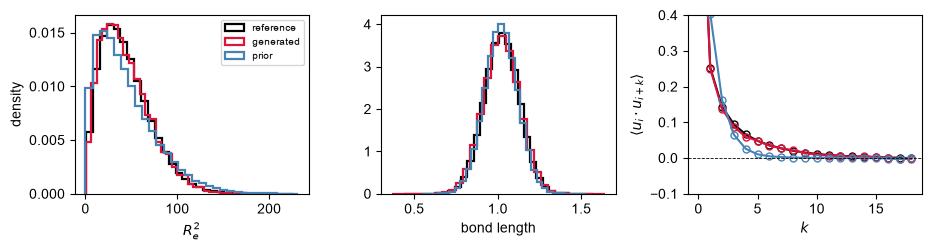

In [14]:
series = [(x1, "reference", "k"), (x_gen, "generated", "crimson") , 
          (x0,        "prior",     "steelblue")]

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.6))
for s, lab, c in series:
    ax[0].hist(end_to_end_sq(s).cpu().numpy(), bins=30, density=True,
               histtype="step", lw=1.6, color=c, label=lab)
    ax[1].hist(bond_lengths(s), bins=30, density=True,
               histtype="step", lw=1.6, color=c, label=lab)
    ax[2].plot(tangent_correlation(s), '-o',mfc='none',ms=5, c=c, label=lab)
ax[0].set_xlabel(r"$R_e^2$"); ax[1].set_xlabel("bond length")
ax[2].set_xlabel("$k$"); ax[2].set_ylabel(r"$\langle u_i \cdot u_{i+k}\rangle$")
ax[2].axhline(0, c="k", lw=0.6, ls="--")
ax[2].set_ylim(-0.1,0.4)
ax[0].set_ylabel("density"); ax[0].legend(fontsize=7)
plt.tight_layout(); plt.show()

#### 4.1. Rouse modes: structure at every length scale at once

$R_e^2$ and $R_g^2$ are global, the bond length and $\langle\cos\theta\rangle$ are local, and
nothing above reports on the chain in between. The Rouse (discrete cosine) modes do:

$$X_k = \sqrt{2/N}\sum_{j=1}^{N} R_j \cos\!\Big(\frac{\pi k (j - \tfrac12)}{N}\Big),
  \qquad k = 0 \ldots N-1.$$

$\langle |X_k|^2\rangle$ versus $k$ is the backbone's structure factor, resolving every
wavelength from the whole chain ($k=1$) down to a single bond ($k=N-1$) in one curve. The
cross-mode covariances $\langle X_k\cdot X_l\rangle$ then catch what a correct spectrum can
still hide: a chain whose modes are individually the right size but wrongly correlated with
each other is not the right chain.

Two conventions. $X_0 = \sqrt{2N}\,\overline{R}$ is the centre of mass, not a structural
mode — it is the one mode that is not translation invariant, and it is dropped from the plots
below. And the uniform $\sqrt{2/N}$ is the polymer literature's normalization, not the
orthonormal DCT-II, so Parseval carries an extra centre-of-mass term (see `rouse_modes`).

Every $X_k$ is O(3)-*equivariant*, so $|X_k|^2$ and $X_k\cdot X_l$ are O(3)-*invariant* —
which is what makes them comparable at all between samples that are only ever defined up to
a rotation.

**What a pass looks like:** the generated spectrum overlays the reference across all $k$,
including the high-$k$ tail where a flow that only matched the global size would drift; and
the difference of the two correlation matrices is featureless at the noise level set by
`n_gen`. A systematic band structure there means structurally inconsistent chains.

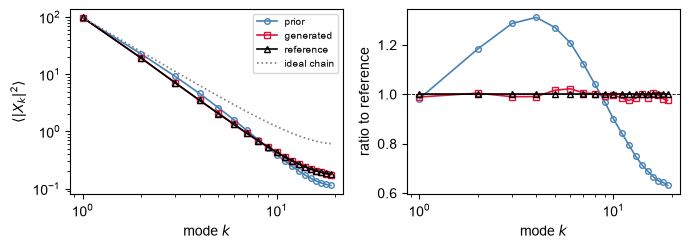

largest |<|X_k|^2> ratio - 1| over k >= 1: 2.5%


In [15]:
# --- Rouse spectra: prior, generated, reference ---
#
# Matched sample sizes, because the off-diagonal covariances below are noisy at small B
# and an unfair comparison would show up there as spurious structure.
rouse = {name: rouse_mode_moments(s)
         for name, s in [("prior", x0), ("generated", x_gen), ("reference", x1)]}
kk = np.arange(1, N)                      # k = 0 is the centre of mass, not a mode

fig, ax = plt.subplots(1, 2, figsize=(7.0, 2.6))
for name, c, m in [("prior", "steelblue", "o"), ("generated", "crimson", "s"),
                   ("reference", "k", "^")]:
    msq = rouse[name][0].cpu().numpy()[1:]
    ax[0].plot(kk, msq, m + "-", mfc="none", ms=4, lw=1.2, c=c, label=name)
    ax[1].plot(kk, msq / rouse["reference"][0].cpu().numpy()[1:], m + "-",
               mfc="none", ms=4, lw=1.2, c=c)

# The ideal-chain shape, 1 / (4 sin^2(pi k / 2N)) ~ k^-2, matched to the data at k = 1.
# A guide to the eye only: this ensemble is tail-anchored and active, not a free
# Gaussian chain, so departures from it are physics rather than error.
ideal = 1.0 / (4.0 * np.sin(np.pi * kk / (2 * N)) ** 2)
ideal *= rouse["reference"][0].cpu().numpy()[1] / ideal[0]
ax[0].plot(kk, ideal, ls=":", lw=1.2, c="grey", label="ideal chain")

ax[0].set_xscale("log"); ax[0].set_yscale("log")
ax[0].set_xlabel("mode $k$"); ax[0].set_ylabel(r"$\langle |X_k|^2 \rangle$")
ax[0].legend(fontsize=7)
ax[1].axhline(1.0, c="k", lw=0.6, ls="--")
ax[1].set_xscale("log")
ax[1].set_xlabel("mode $k$"); ax[1].set_ylabel(r"ratio to reference")
plt.tight_layout(); plt.show()

worst = np.abs(rouse["generated"][0].cpu().numpy()[1:]
               / rouse["reference"][0].cpu().numpy()[1:] - 1).max()
print(f"largest |<|X_k|^2> ratio - 1| over k >= 1: {100*worst:.1f}%")

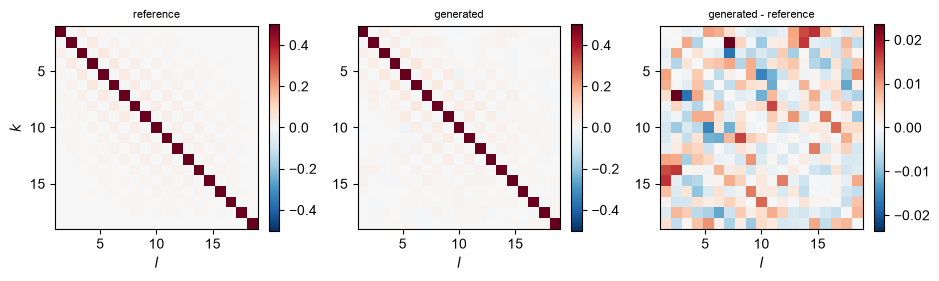

RMS off-diagonal difference : 0.0063
max |difference|            : 0.0235
noise floor ~ 1/sqrt(3*n_gen): 0.0058


In [16]:
# --- cross-mode correlations: what the spectrum alone cannot see ---
#
# cov[k,l] / sqrt(msq[k] msq[l]), so the diagonal is 1 by construction and every
# off-diagonal is a genuine correlation between two length scales. Modes k >= 1 only.
def corr(name):
    msq, cov = (t.cpu().numpy() for t in rouse[name])
    c = cov / np.sqrt(np.outer(msq, msq))
    return c[1:, 1:]

c_ref, c_gen = corr("reference"), corr("generated")
diff = c_gen - c_ref
ext = dict(extent=[1, N-1, N-1, 1])

fig, ax = plt.subplots(1, 3, figsize=(9.5, 2.9))
for a, (m, lab, vlim, cmap) in zip(ax, [
    (c_ref,  "reference",            0.5, "RdBu_r"),
    (c_gen,  "generated",            0.5, "RdBu_r"),
    (diff,   "generated - reference", np.abs(diff).max(), "RdBu_r"),
]):
    im = a.imshow(m, vmin=-vlim, vmax=vlim, cmap=cmap, **ext)
    a.set_title(lab, fontsize=8)
    a.set_xlabel("$l$")
    fig.colorbar(im, ax=a, fraction=0.046)
ax[0].set_ylabel("$k$")
plt.tight_layout(); plt.show()

# The single number: how far the generated correlation structure is from the reference,
# against the sampling noise floor implied by n_gen. Off-diagonals of an uncorrelated
# pair fluctuate at ~1/sqrt(3*n_gen) (three spatial components per sample).
off = ~np.eye(N-1, dtype=bool)
print(f"RMS off-diagonal difference : {np.sqrt((diff[off]**2).mean()):.4f}")
print(f"max |difference|            : {np.abs(diff[off]).max():.4f}")
print(f"noise floor ~ 1/sqrt(3*n_gen): {1/np.sqrt(3*len(x_gen)):.4f}")

### 5. Entropy estimates

The quantity of interest, and the reason for the whole construction: $\Delta S$ from prior to
target. Both interpolant estimators are available (`"dot"`, the inner product $b\cdot s$, and
`"div"`, the exact subspace divergence over the $3(N-1)$ anchored directions).

There is **no free-energy cross-check here**, unlike the LJ13 notebook — at least not for
an active chain. That is not an omission: an active polymer has no target potential, so
$-\log \tilde p_1(x)$ does not exist and no importance-weighted estimate of $\Delta F$ can be
formed. The absolute entropy of the target follows from the prior's analytic entropy plus the
measured change: $S[p_1] = S[p_0] + \Delta S$.

At $\mathrm{Pe} = 0$ the target *is* Boltzmann, and there an external check does exist —
thermodynamic integration from a bending-free ideal chain. Section 6 reconciles the two, which
needs the angle potential read back in analytically.

Note that $\Delta S$ is *not* comparable across priors — only $S[p_1]$ is. A better-matched
prior moves $S[p_0]$ and $\Delta S$ in opposite directions by construction, so a smaller
$|\Delta S|$ here is a statement about the flow's workload, not about the target. What should
be stable, and is the real check on the calibration, is their sum.

In [47]:
torch.manual_seed(5)
n_batches = 100
means_dot, means_zdot, means_div = [], [], []
for _ in range(n_batches):
    idx = torch.randint(0, x1.shape[0], (batch_size,), device=device)
    xb = x1[idx]
    xa = sample_prior(batch_size, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                      n_particles=N, device=device)
    xa, xb = tap_ot_couple(xa, xb, batch=True)
    means_dot.append(model.entropy_estimate(xb, xa, method="dot").mean().item())
    means_zdot.append(model.entropy_estimate(xb, xa, method="zdot").mean().item())
    means_div.append(model.entropy_estimate(xb, xa, method="div").mean().item())

ci = lambda v: 1.96 * np.std(v) / np.sqrt(len(v))
print(f"dS (b.s)   : {np.mean(means_dot):+.3f} +/- {ci(means_dot):.3f}")
print(f"dS (b.z)   : {np.mean(means_zdot):+.3f} +/- {ci(means_zdot):.3f}")
print(f"dS (div b) : {np.mean(means_div):+.3f} +/- {ci(means_div):.3f}")
print(f"\nS[p0] (analytic) = {S_prior:+.3f}")
print(f"S[p1] = S[p0] + dS = {S_prior + np.mean(means_div):+.3f} nats")

dS (b.s)   : +0.299 +/- 0.194
dS (b.z)   : +1.254 +/- 0.197
dS (div b) : +1.468 +/- 0.155

S[p0] (analytic) = +25.148
S[p1] = S[p0] + dS = +26.616 nats


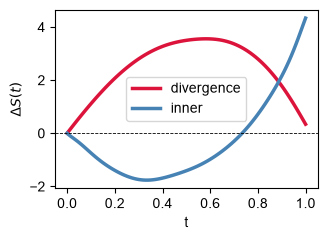

In [15]:
# Running entropy change along many ODE paths.
torch.manual_seed(6)
x0 = sample_prior(2_000, K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0,
                  n_particles=N, device=device)
_, ent_div, ts = model.sample(x0, n_steps=100, return_traj=True, entropy='div')
_, ent_dot, ts  = model.sample(x0, n_steps=100, return_traj=True, entropy='dot')
ts_c = ts.cpu().numpy()
ent_c_div, ent_c_dot = ent_div.cpu().numpy(), ent_dot.cpu().numpy()
ent_c_dot = ent_dot.cpu().numpy()

fig, ax = plt.subplots(figsize=(3.375, 2.5))
ax.plot(ts_c, ent_c_div.mean(axis=1), c="crimson", lw=2.5, label="divergence")
ax.plot(ts_c, ent_c_dot.mean(axis=1), c="steelblue", lw=2.5, label="inner")
ax.axhline(0.0, c="k", lw=0.6, ls="--")
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
ax.legend(); plt.tight_layout(); plt.show()

In [16]:
print(ent_c_div.mean(axis=1)[-1])
print(ent_c_div.std(axis=1)[-1])
print(ent_c_dot.mean(axis=1)[-1])
print(ent_c_dot.std(axis=1)[-1])

0.34077457508495024
1.816020705157591
4.33370645535379
6.322868395883383


In [17]:
np.save("ent_c_div.npy",ent_c_div)
np.save("ent_c_dot.npy",ent_c_dot)

np.save("means_dot.npy",means_dot)
np.save("means_div.npy",means_div)
np.save("means_zdot.npy",means_zdot)

In [35]:
def strap(data,n_straps):
    data_size = len(data)
    means = np.zeros(n_straps)
    rng = np.random.default_rng()
    for i in range(n_straps):
        means[i] = np.mean(rng.choice(data, 
                                    size=data_size, 
                                    replace=True, 
                                    p=None, 
                                    axis=0, 
                                    shuffle=True))
    return means.mean(), 1.96*means.std()

print(strap(ent_c_div[-1],100_000))
print(strap(ent_c_dot[-1],100_000))
print(strap(means_dot,100_000))
print(strap(means_zdot,100_000))
print(strap(means_div,100_000))


(np.float64(0.3406963060120566), np.float64(0.07975175814958632))
(np.float64(4.333469027535667), np.float64(0.27826702055632013))
(np.float64(-0.3348475359290282), np.float64(0.6686183216378758))
(np.float64(0.5054595159329746), np.float64(0.5574947512907041))
(np.float64(1.1590724483199306), np.float64(0.4608995017031118))


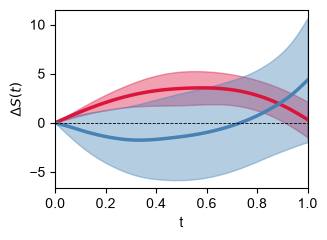

In [19]:
fig, ax = plt.subplots(figsize=(3.375, 2.5))
#ax.plot(ts_c, ent_c_div, c="crimson", lw=0.4, alpha=0.1)

ax.fill_between(ts_c,
                ent_c_div.mean(axis=1)-ent_c_div.std(axis=1),
                ent_c_div.mean(axis=1)+ent_c_div.std(axis=1),
                color='crimson',alpha=0.4)
ax.plot(ts_c, ent_c_div.mean(axis=1), c="crimson", lw=2.5, label="divergence")

ax.fill_between(ts_c,
                ent_c_dot.mean(axis=1)-ent_c_dot.std(axis=1),
                ent_c_dot.mean(axis=1)+ent_c_dot.std(axis=1),
                color='steelblue',alpha=0.4)
ax.plot(ts_c, ent_c_dot.mean(axis=1), c="steelblue", lw=2.5, label="inner")
#ax.plot(ts_c, ent_c_dot.mean(axis=1), c="steelblue", lw=2.5, label="inner")
#ax.plot(ts_c, ent_c_dot, c="steelblue", lw=0.4, alpha=0.1)
ax.axhline(0.0, c="k", lw=0.6, ls="--")
plt.xlim(0,1)
ax.set_xlabel("t"); ax.set_ylabel(r"$\Delta S(t)$")
plt.tight_layout(); plt.show()

In [3]:
df = pd.read_csv("../../runs/tap_Pe0_train2/entropy/means.csv")
df.columns

Index(['batch', 'dot', 'zdot', 'div'], dtype='str')

In [4]:
import scipy.stats
def boot(data,n,alpha=0.95):
    straps = [np.mean(np.random.choice(data,len(data),replace=True)) for _ in range(n)]
    return float(np.mean(straps)),float(scipy.stats.t.ppf(0.5*(1+alpha),n-1)*np.std(straps))

ci = lambda v: 1.96 * np.std(v) / np.sqrt(len(v))

In [5]:
print(boot(df['dot'],10000))
print(boot(df['zdot'],10000))
print(boot(df['div'],10000))

(1.9903106703155615, 0.07317621400984729)
(1.75604720762689, 0.0753365180991056)
(1.8791301335933, 0.056719764196717926)


In [25]:
means_div = df["div"]
means_zdot = df["zdot"]
means_dot = df["dot"]

### 6. Reconciling with thermodynamic integration ($\mathrm{Pe} = 0$ only)

For the passive chain there is an independent result to check against: thermodynamic
integration from an **ideal reference** — the same harmonic bonds, no excluded volume, and
**no bending potential** — to the full system. The interpolant measures something else: its
$\Delta S$ starts from the flow's **prior**, which is that same chain *plus* the fitted
bending potential $\gamma(\cos\theta-\cos\theta_0)^2$. The two reference states differ by
exactly one term, so the results are reconciled by reading that term back in:

$$\underbrace{\Delta S_{\rm TI}}_{\rm ideal\,\to\,full}
  = \underbrace{\Delta S_{\rm interp}}_{\rm prior\,\to\,full}
  + \underbrace{\Delta S_{\rm bend}}_{\rm ideal\,\to\,prior},$$

or equivalently, as two routes to one absolute entropy,
$S[p_1] = S_{\rm ideal} + \Delta S_{\rm TI} = S[p_0] + \Delta S_{\rm interp}$.

The bridge is closed-form and, because the bond law $p(Q)\propto Q^2e^{-\frac{k}{2}(Q-b)^2}$ is
*identical* in both states, every radial term cancels and it depends on $(\gamma,\cos\theta_0)$
alone — not on $k$ or $b$. With $Z_{\rm ang}=2$ for the uniform (freely-jointed) law,

$$\Delta U_{\rm bend} = (N-2)\,\gamma\,\mathbb{E}[(u-u_0)^2],\qquad
  \Delta F_{\rm bend} = -(N-2)\log\frac{Z_{\rm ang}}{2},\qquad
  \Delta S_{\rm bend} = \Delta U_{\rm bend} - \Delta F_{\rm bend}.$$

Both signs are the physical ones: the bending potential constrains the chain, so it *costs*
free energy and *removes* entropy. `bending_deltas` returns the triple; `prior_energy` and
`prior_free_energy` give the absolute $\langle U\rangle$ and $F=-\log Z$ that it differences,
and satisfy $S = \langle U\rangle - F$ exactly against `prior_entropy`.

**Conventions that must match, because every one of them is a silent constant.**

1. *Translational gauge.* Everything here lives on the tail-anchored subspace, dimension
   $3(N-1)$. A TI calculation in a box carries an extra $\log V$ — which **cancels**, because
   it is the same factor in ideal $\to$ full and in ideal $\to$ prior alike.
2. *Kinetic terms.* Momentum integrals cancel in every difference; only the configurational
   part is ever compared.
3. *Units.* $k_BT = 1$, nats, **per chain** — $N-1 = 19$ bonds and $N-2 = 18$ angles. A
   per-monomer TI number is a factor of $20$ away from this.
4. *Sign.* Every $\Delta$ is (final $-$ initial), with initial the *less* constrained state.
5. *Bond parameters.* TI's ideal must use the simulation's own $(k, b)$ — see the next cell,
   which computes the offset rather than assuming it away.
6. *Excluded volume.* Off in TI's reference, as it is in the prior.

This section applies to $\mathrm{Pe} = 0$ only. TI needs an equilibrium target; at
$\mathrm{Pe} > 0$ there is nothing to reconcile against and the interpolant stands alone.

In [23]:
# --- 6.1 the analytic bridge, ideal (bonds only) -> prior (bonds + angle) ---
#
# K_SIM, B_SIM are the SIMULATION's bond Hamiltonian, and must be the same numbers TI
# integrated from. They are also what section 1 sets K_BOND / B_BOND to by hand (the
# measured 1/var(Q) = 91.3 and E[Q] = 1.024 are close but are NOT the Hamiltonian), so
# the bond offset below is normally exactly zero -- computed anyway, because if the two
# ever diverge the reconciliation is wrong by a constant nothing else would reveal.
K_SIM, B_SIM = 100.0, 1.0

IS_PASSIVE = "Pe0" in str(DATA)
if not IS_PASSIVE:
    print(f"{DATA} is not the passive (Pe=0) dataset -- no TI result to reconcile "
          f"against, so section 6 is a no-op. The interpolant's dS stands alone.\n")

dS_bend, dU_bend, dF_bend = bending_deltas(GAMMA_BEND, COS_THETA_0, N)

# The three potentials of each reference state. `ideal` is TI's starting point, `prior`
# the flow's; their difference is the bridge that moves one result onto the other.
ideal = np.array([prior_entropy(K_SIM, B_SIM, 0.0, 0.0, N),
                  prior_energy(K_SIM, B_SIM, 0.0, 0.0, N),
                  prior_free_energy(K_SIM, B_SIM, 0.0, 0.0, N)])
prior = np.array([prior_entropy(K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, N),
                  prior_energy(K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, N),
                  prior_free_energy(K_BOND, B_BOND, GAMMA_BEND, COS_THETA_0, N)])
bridge = prior - ideal                      # (dS, dU, dF), ideal -> prior

# With matched bond parameters the bridge IS the bending term, and the remainder is the
# bond-law offset -- kept explicit rather than assumed away.
bond_offset = bridge - np.array([dS_bend, dU_bend, dF_bend])

print(f"{'':<26}{'S':>12}{'U':>12}{'F':>12}")
print(f"{'ideal (bonds only)':<26}" + "".join(f"{v:12.4f}" for v in ideal))
print(f"{'prior (bonds + angle)':<26}" + "".join(f"{v:12.4f}" for v in prior))
print(f"{'bridge (ideal -> prior)':<26}" + "".join(f"{v:+12.4f}" for v in bridge))
print(f"{'  of which bending':<26}"
      + "".join(f"{v:+12.4f}" for v in (dS_bend, dU_bend, dF_bend)))
print(f"{'  of which bond mismatch':<26}" + "".join(f"{v:+12.4f}" for v in bond_offset))

# Two identities worth asserting in the notebook and not only in the test suite: the
# first catches a stale S_prior (i.e. a calibration that has drifted away from the
# trained model), the second that S = U - F holds for both states -- no 4pi/2pi slip.
assert abs(prior[0] - S_prior) < 1e-9, "S_prior is stale -- re-run the calibration cell"
assert abs(prior[0] - (prior[1] - prior[2])) < 1e-9
assert abs(ideal[0] - (ideal[1] - ideal[2])) < 1e-9

                                     S           U           F
ideal (bonds only)             31.6774      9.6881    -21.9892
prior (bonds + angle)          25.1414     16.0439     -9.0976
bridge (ideal -> prior)        -6.5359     +6.3558    +12.8917
  of which bending             -6.5359     +6.3558    +12.8917
  of which bond mismatch       -0.0000     +0.0000     +0.0000


In [29]:
# --- 6.2 the reconciliation ---
#
# Thermodynamic integration, ideal (harmonic bonds at K_SIM/B_SIM, no EV, no bending)
# -> full passive chain. Per chain, in kT / nats, sign convention X_full - X_ideal.
# Fill these in from the TI run; leave any as None to skip that line.
TI = {"dS": -4.60657711, "dU": 0.77741289, "dF": 5.38399}

# The interpolant's own dS (prior -> full), from section 5. "div" is the estimator the
# absolute entropy is quoted from there; the other two are consistency checks on the
# model rather than independent measurements.
dS_interp, dS_err = np.mean(means_zdot), ci(means_zdot)

if TI["dS"] is None:
    print("TI[...] not filled in -- printing the flow's side only.\n")
else:
    # Move the TI result onto the prior's reference state by subtracting the bridge.
    ti_prior = {key: (None if v is None else v - off)
                for (key, v), off in zip(TI.items(), bridge)}
    resid = dS_interp - ti_prior["dS"]
    print(f"dS  TI (ideal -> full)   : {TI['dS']:+9.3f}")
    print(f"    bridge (ideal->prior): {bridge[0]:+9.3f}")
    print(f"    TI, prior-referenced : {ti_prior['dS']:+9.3f}")
    print(f"    interpolant          : {dS_interp:+9.3f} +/- {dS_err:.3f}")
    print(f"    residual             : {resid:+9.3f}   ({abs(resid)/dS_err:.1f} sigma)\n")
    for key in ("dU", "dF"):
        if TI[key] is not None:
            print(f"{key}  TI (ideal -> full)   : {TI[key]:+9.3f}"
                  f"    prior-referenced: {ti_prior[key]:+9.3f}")
    # The flow measures the entropy TI would otherwise have to integrate for, so pairing
    # it with the prior-referenced energy gives a free energy the flow alone cannot see.
    if TI["dU"] is not None:
        print(f"\ndF (prior -> full) from dU_TI - dS_interp: "
              f"{ti_prior['dU'] - dS_interp:+9.3f}")

# The absolute entropy of the target, by both routes -- the same statement as a number.
print(f"\nS[p1] = S[prior] + dS_interp = {prior[0] + dS_interp:+9.3f} nats")
if TI["dS"] is not None:
    print(f"S[p1] = S[ideal] + dS_TI     = {ideal[0] + TI['dS']:+9.3f} nats")

dS  TI (ideal -> full)   :    -4.607
    bridge (ideal->prior):    -6.536
    TI, prior-referenced :    +1.929
    interpolant          :    +1.720 +/- 0.075
    residual             :    -0.209   (2.8 sigma)

dU  TI (ideal -> full)   :    +0.777    prior-referenced:    -5.578
dF  TI (ideal -> full)   :    +5.384    prior-referenced:    -7.508

dF (prior -> full) from dU_TI - dS_interp:    -7.299

S[p1] = S[prior] + dS_interp =   +26.862 nats
S[p1] = S[ideal] + dS_TI     =   +27.071 nats


**Reading the residual.** A non-zero answer is diagnosable rather than fatal:

* **large compared with the flow's error bar, and insensitive to more training** — a
  convention mismatch, not a model error. Walk the six-point checklist in 6.0; the usual
  culprits are per-monomer vs per-chain units and a TI reference whose $(k,b)$ are not the
  simulation's.
* **shrinking as training continues** — the flow, not the bridge. The interpolant's
  $\Delta S$ is the only term here that is not exact.
* **changing when $\gamma$ / $\cos\theta_0$ are recalibrated without retraining** — the prior
  and the trained model have gone out of sync. The assertion in 6.1 catches the blatant case
  (a stale $S[p_0]$); this catches the subtle one.

Note also what the bridge does *not* change: $S[p_1]$ itself. A different prior moves
$S[p_0]$ and $\Delta S_{\rm interp}$ in opposite directions by construction (section 5), and
this is exactly the bookkeeping that makes that cancellation explicit.

In [3]:
import json

dnames = ["tap_Pe0_train2", "tap_Pe0p01", "tap_Pe0p03","tap_Pe0p1","tap_Pe0p3",
            "tap_Pe1","tap_Pe3","tap_Pe10","tap_Pe30","tap_Pe100"]
S0 = 31.6774
S1_zdot = []
S1_dot = []
S1_div = []
for dname in dnames:
    with open(f"../../runs/{dname}/entropy/summary.json", "r") as f:
        summary = json.load(f)
    #print(summary['S_prior'])
    #print(summary['batches']['zdot']['S_target'])
    S1_zdot.append(summary['batches']['zdot']['S_target'])

S_ex_z = np.array(S1_zdot) - S0
Pe = np.array([0,0.01,0.03,0.1,0.3,1,3,10,30,100])



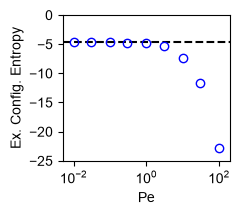

In [7]:
plt.figure(figsize=(2.5,2.25))
plt.hlines(-4.607,5e-3,200,color='k',ls='--')
#plt.hlines(S_ex_z[0],5e-3,200,color='k',ls='--')
plt.plot(Pe,S_ex_z,'bo',mfc='none')
plt.xscale('log')
plt.xlabel('Pe')
plt.ylabel('Ex. Config. Entropy')
plt.ylim(-25,0)
plt.xlim(5e-3,200)
plt.tight_layout()
plt.show()

